## 1. Import Libraries

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

## 2. Device Setup (GPU/CPU)

In [60]:
base_path = "/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset"

## Data Path

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# simple test model
model = BaselineCNN().to(device) 

criterion = nn.BCEWithLogitsLoss()  
optimizer = optim.Adam(model.parameters(), lr=0.001)

cuda


## 3. Basic Transform

In [62]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Normalizing makes the model train more stably
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_path = "/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset"

train_dataset = datasets.ImageFolder(base_path + "/train", transform=transform)


In [63]:
# Verify Model
print(train_dataset.classes)
print(set([label for _, label in train_dataset]))

['benign', 'malignant']
{0, 1}


## 4. Load Dataset

In [64]:
train_dataset = datasets.ImageFolder(base_path + "/train", transform=transform)
val_dataset   = datasets.ImageFolder(base_path + "/val", transform=transform)
test_dataset  = datasets.ImageFolder(base_path + "/test", transform=transform)

## 5. Visualize Some Images



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


torch.Size([32, 3, 224, 224])
tensor([1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
        0, 1, 1, 1, 1, 1, 1, 0])


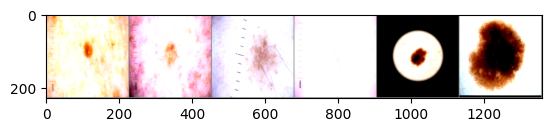

Labels: tensor([0, 0, 0, 0, 1, 0])


In [65]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

dataiter = iter(train_loader)
images, labels = next(dataiter)

print(images.shape)
print(labels)
import numpy as np
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:6]))
print("Labels:", labels[:6])

### 5.1. Class Distribution of Training Dataset

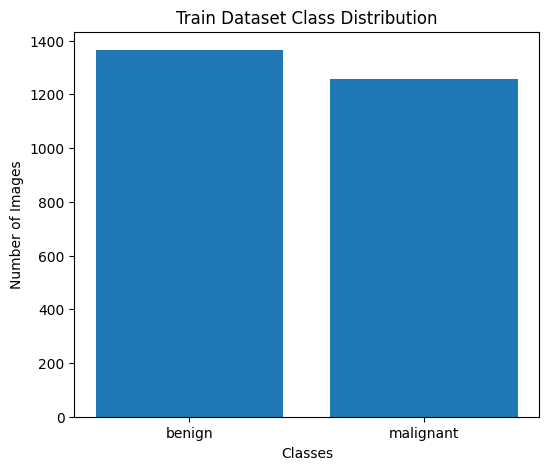

In [66]:
from collections import Counter
import matplotlib.pyplot as plt

# Get labels from TRAIN dataset
labels = [label for _, label in train_dataset]

# Count classes
class_counts = Counter(labels)

# Class names (benign, malignant)
class_names = train_dataset.classes

# Convert counts in correct order
counts = [class_counts[i] for i in range(len(class_names))]

# Plot
plt.figure(figsize=(6, 5))
plt.bar(class_names, counts)

plt.title("Train Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

## Check Classes

In [67]:
print("Classes:", train_dataset.classes)

Classes: ['benign', 'malignant']


## 6. Baseline CNN Model (From Scratch)

### Architecture: Conv → ReLU → MaxPool → Dense → Sigmoid

In [68]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        # 224 -> 112 -> 56 -> 28
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 1) # Binary Output

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 6.1. Initialize Model, Loss, Optimizer

In [69]:
model = BaselineCNN().to(device)
criterion = nn.BCEWithLogitsLoss()  
optimizer = optim.Adam(model.parameters(), lr=0.001)


## 10. Training

In [70]:
epochs = 10
best_val_acc = 0.0  # Track best accuracy to save the best model

print("Starting Training...")
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().view(-1, 1)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float().view(-1, 1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss_avg = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    # SAVE BEST MODEL LOGIC
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_baseline_model.pth")
        save_msg = "(Best Model Saved!)"
    else:
        save_msg = ""

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.4f} {save_msg}")

Starting Training...
Epoch 1/10 | Train Loss: 0.4182 | Train Acc: 0.8117 | Val Loss: 0.2818 | Val Acc: 0.8856 (Best Model Saved!)
Epoch 2/10 | Train Loss: 0.3128 | Train Acc: 0.8795 | Val Loss: 0.2825 | Val Acc: 0.8884 (Best Model Saved!)
Epoch 3/10 | Train Loss: 0.3098 | Train Acc: 0.8723 | Val Loss: 0.2873 | Val Acc: 0.8876 
Epoch 4/10 | Train Loss: 0.2707 | Train Acc: 0.8933 | Val Loss: 0.2558 | Val Acc: 0.8969 (Best Model Saved!)
Epoch 5/10 | Train Loss: 0.2529 | Train Acc: 0.8952 | Val Loss: 0.2479 | Val Acc: 0.9000 (Best Model Saved!)
Epoch 6/10 | Train Loss: 0.2484 | Train Acc: 0.9013 | Val Loss: 0.2587 | Val Acc: 0.8972 
Epoch 7/10 | Train Loss: 0.2223 | Train Acc: 0.9055 | Val Loss: 0.2421 | Val Acc: 0.9058 (Best Model Saved!)
Epoch 8/10 | Train Loss: 0.2238 | Train Acc: 0.9096 | Val Loss: 0.2580 | Val Acc: 0.9043 
Epoch 9/10 | Train Loss: 0.2047 | Train Acc: 0.9165 | Val Loss: 0.2698 | Val Acc: 0.9025 
Epoch 10/10 | Train Loss: 0.2065 | Train Acc: 0.9199 | Val Loss: 0.2322 | 

## 11. Final Test Accuracy

In [71]:
print("\n--- Loading Best Model for Final Test ---")
model.load_state_dict(torch.load("best_baseline_model.pth"))
model.eval()

test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float().view(-1, 1)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

final_test_acc = test_correct / test_total
print(f"FINAL TEST ACCURACY: {final_test_acc*100:.2f}%")


--- Loading Best Model for Final Test ---
FINAL TEST ACCURACY: 90.80%


## 12. Plotting diagram

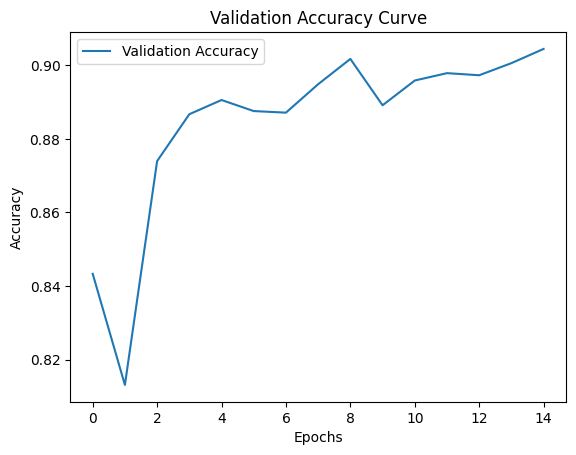

In [73]:
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Validation Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Showing in confusion matrix

In [74]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:   # change to test_loader if available
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        

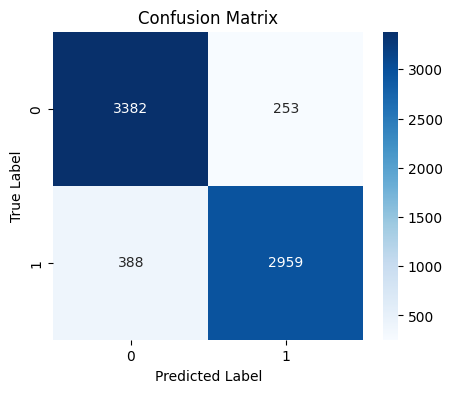

In [75]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [76]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.90      0.93      0.91      3635
         1.0       0.92      0.88      0.90      3347

    accuracy                           0.91      6982
   macro avg       0.91      0.91      0.91      6982
weighted avg       0.91      0.91      0.91      6982



## 12. Predicting 

In [77]:
def predict_image_with_confidence(image_path):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        # Predicted class
        predicted = torch.argmax(outputs, dim=1)

        # Confidence (softmax probability)
        probs = F.softmax(outputs, dim=1)
        confidence = probs[0, predicted.item()]

    return class_names[predicted.item()], confidence.item() * 100

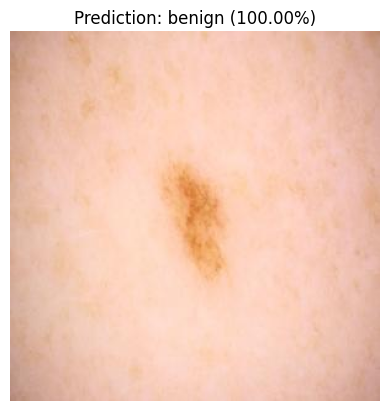

In [78]:
from PIL import Image
def show_prediction(image_path):
    predicted_class, confidence = predict_image_with_confidence(image_path)

    # Load image only for display
    image = Image.open(image_path)

    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset/train/benign/melanoma_1015.jpg")

---
# Improved CNN (Optimized Model)

## 13. Data Augmentation + Preprocessing

In [80]:
import os
#0. Setup and Data Augmentation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_path = "/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(os.path.join(base_path, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(base_path, "val"), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(base_path, "test"), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [81]:
# 1. Improved CNN Architecture
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.flatten_size = self._get_flatten_size()
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def _get_flatten_size(self):
        with torch.no_grad():
            x = torch.randn(1, 3, 224, 224)
            x = self.features(x)
            return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [82]:
# 2. Initialize Model
model = ImprovedCNN().to(device) # FIXED: No longer using the simple Linear model
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [83]:
# 3. Training Loop with Early Stopping
epochs = 15
best_val_acc = 0
patience = 5
counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Training Improved CNN...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().view(-1, 1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float().view(-1, 1)
            outputs = model(images)
            v_loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            v_correct += (preds == labels).sum().item()
            v_total += labels.size(0)

    val_loss = v_loss / len(val_loader)
    val_acc = v_correct / v_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # SAVE BEST AND EARLY STOPPING
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_improved_model.pth")
        print("Best Model Saved!")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Training Improved CNN...
Epoch 1 | Train Acc: 0.7061 | Val Acc: 0.8034
Best Model Saved!
Epoch 2 | Train Acc: 0.7495 | Val Acc: 0.8274
Best Model Saved!
Epoch 3 | Train Acc: 0.7415 | Val Acc: 0.8154
Epoch 4 | Train Acc: 0.7308 | Val Acc: 0.8409
Best Model Saved!
Epoch 5 | Train Acc: 0.7457 | Val Acc: 0.8417
Best Model Saved!
Epoch 6 | Train Acc: 0.7732 | Val Acc: 0.8565
Best Model Saved!
Epoch 7 | Train Acc: 0.7800 | Val Acc: 0.8747
Best Model Saved!
Epoch 8 | Train Acc: 0.7709 | Val Acc: 0.8529
Epoch 9 | Train Acc: 0.7774 | Val Acc: 0.8753
Best Model Saved!
Epoch 10 | Train Acc: 0.7976 | Val Acc: 0.8632
Epoch 11 | Train Acc: 0.7911 | Val Acc: 0.8562
Epoch 12 | Train Acc: 0.7991 | Val Acc: 0.8582
Epoch 13 | Train Acc: 0.8052 | Val Acc: 0.8591
Epoch 14 | Train Acc: 0.8052 | Val Acc: 0.8631
Early stopping triggered.


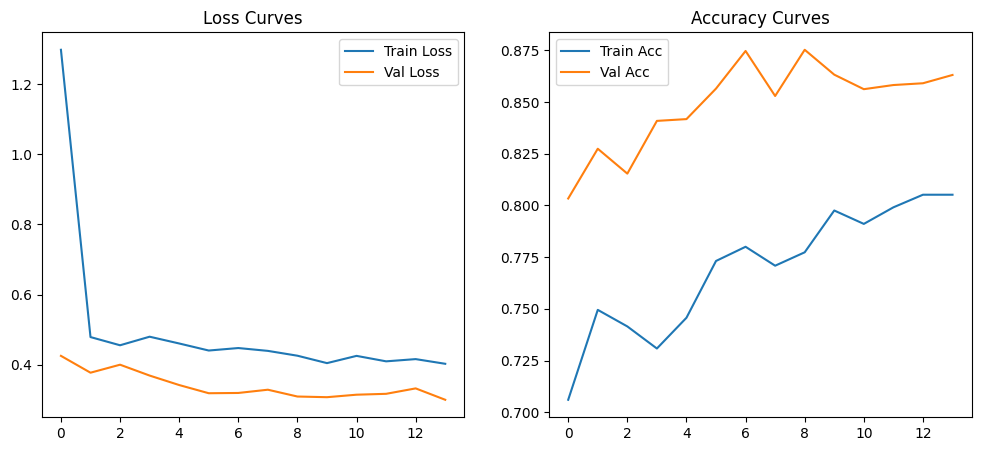

In [84]:
# 4. PLOTS (Loss & Accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()


In [85]:
# 5. FINAL EVALUATION (Confusion Matrix & Classification Report)
print("\n--- Final Evaluation on Test Set ---")
model.load_state_dict(torch.load("best_improved_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())



--- Final Evaluation on Test Set ---


              precision    recall  f1-score   support

      benign       0.86      0.92      0.89       500
   malignant       0.92      0.86      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



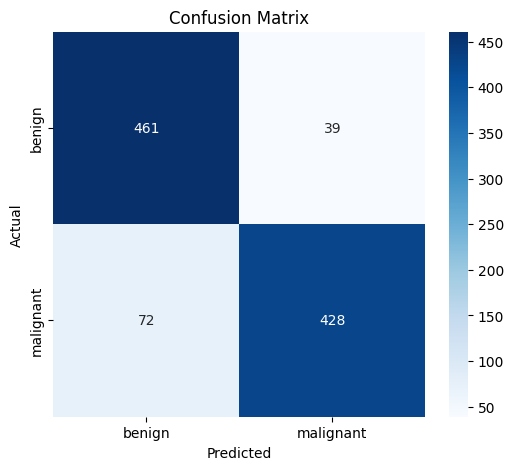

In [86]:
# Classification Report
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

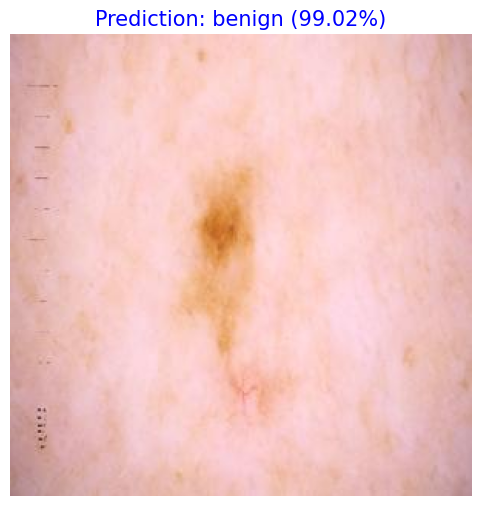

In [89]:
def predict_and_display(image_path, model, transform, device, class_names):
    # 1. Load image
    image = Image.open(image_path).convert("RGB")
    
    # 2. Preprocess for the model
    input_tensor = transform(image).unsqueeze(0).to(device)

    # 3. Predict
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        # Note: Use sigmoid for ImprovedCNN (1 output node) 
        # or softmax for ResNet (2 output nodes)
        if output.shape[1] == 1: # Binary 1-node logic
            probability = torch.sigmoid(output).item()
            if probability > 0.5:
                label, confidence = class_names[1], probability * 100
            else:
                label, confidence = class_names[0], (1 - probability) * 100
        else: # Multi-class/ResNet 2-node logic
            probs = torch.softmax(output, dim=1)
            confidence, predicted_idx = torch.max(probs, 1)
            label, confidence = class_names[predicted_idx.item()], confidence.item() * 100

    # --- THE MISSING PART: DISPLAY THE IMAGE ---
    plt.figure(figsize=(6, 6))
    plt.imshow(image) # This shows the original PIL image
    plt.axis("off")   # Hide the x and y axis numbers
    plt.title(f"Prediction: {label} ({confidence:.2f}%)", fontsize=15, color='blue')
    plt.show()        # Actually renders the plot

    return label, confidence

# --- Run it ---
img_path = "/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset/test/benign/melanoma_10004.jpg"

# Use the transform that matches your model (val_test_transform or resnet_transform)
label, score = predict_and_display(img_path, model, val_test_transform, device, train_dataset.classes)

---
# 9. Pre-Trained Model (ResNet18)

In [90]:
# 1. Setup & Data Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ImageNet Standard Normalization
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Paths (Ensure these match your Kaggle/Local folders)
base_path = "/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset"
train_dataset = datasets.ImageFolder(os.path.join(base_path, "train"), transform=resnet_transform)
val_dataset   = datasets.ImageFolder(os.path.join(base_path, "val"), transform=resnet_transform)
test_dataset  = datasets.ImageFolder(os.path.join(base_path, "test"), transform=resnet_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [93]:
from torchvision import models
class_names = train_dataset.classes
num_classes = len(class_names)

# 2. Model Definition (Transfer Learning)
# Using modern weights parameter
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Selective Freezing: Freeze all layers except layer4 and fc
for name, param in model.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


In [94]:
# 3. Loss & Optimizer
criterion = nn.CrossEntropyLoss()
# Filter only trainable parameters for the optimizer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

In [95]:
# 4. Training Loop
epochs = 15 # Reduced to 15 for efficient fine-tuning
best_val_acc = 0.0

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Starting ResNet18 Fine-Tuning on {device}...")

for epoch in range(epochs):
    # TRAINING
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Metrics
    t_loss = train_loss / len(train_loader)
    t_acc  = train_correct / train_total
    v_loss = val_loss / len(val_loader)
    v_acc  = val_correct / val_total
    
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    # Save Best Model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "resnet18_melanoma_best.pth")
        save_status = "(Best Model Saved!)"
    else:
        save_status = ""

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} {save_status}")



Starting ResNet18 Fine-Tuning on cuda...
Epoch 1/15 | Train Acc: 0.8776 | Val Acc: 0.8979 (Best Model Saved!)
Epoch 2/15 | Train Acc: 0.9382 | Val Acc: 0.9320 (Best Model Saved!)
Epoch 3/15 | Train Acc: 0.9680 | Val Acc: 0.9242 
Epoch 4/15 | Train Acc: 0.9840 | Val Acc: 0.9280 
Epoch 5/15 | Train Acc: 0.9889 | Val Acc: 0.9204 
Epoch 6/15 | Train Acc: 0.9912 | Val Acc: 0.9231 
Epoch 7/15 | Train Acc: 0.9897 | Val Acc: 0.9158 
Epoch 8/15 | Train Acc: 0.9920 | Val Acc: 0.9242 
Epoch 9/15 | Train Acc: 0.9901 | Val Acc: 0.9205 
Epoch 10/15 | Train Acc: 0.9897 | Val Acc: 0.9255 
Epoch 11/15 | Train Acc: 0.9947 | Val Acc: 0.9238 
Epoch 12/15 | Train Acc: 0.9947 | Val Acc: 0.9334 (Best Model Saved!)
Epoch 13/15 | Train Acc: 0.9985 | Val Acc: 0.9310 
Epoch 14/15 | Train Acc: 0.9970 | Val Acc: 0.9285 
Epoch 15/15 | Train Acc: 0.9970 | Val Acc: 0.9294 


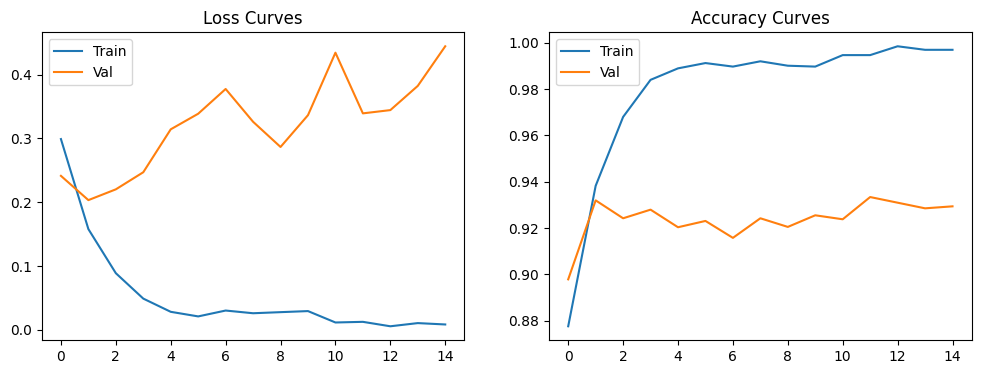

In [96]:
# 5. Visualizing Performance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy Curves")
plt.legend()
plt.show()


In [97]:
# 6. Final Evaluation (Test Set)
print("\n--- Final Test Evaluation ---")
model.load_state_dict(torch.load("resnet18_melanoma_best.pth"))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))



--- Final Test Evaluation ---
              precision    recall  f1-score   support

      benign       0.90      0.94      0.92       500
   malignant       0.94      0.90      0.92       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



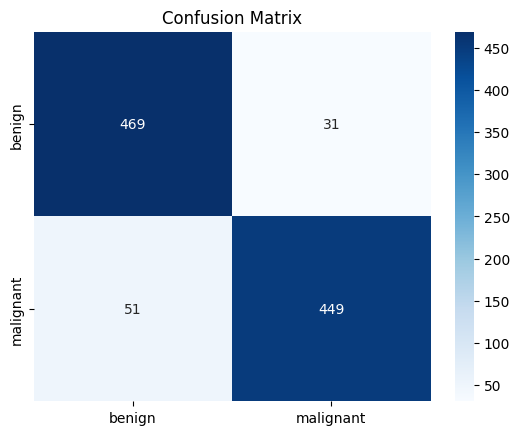

In [98]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()


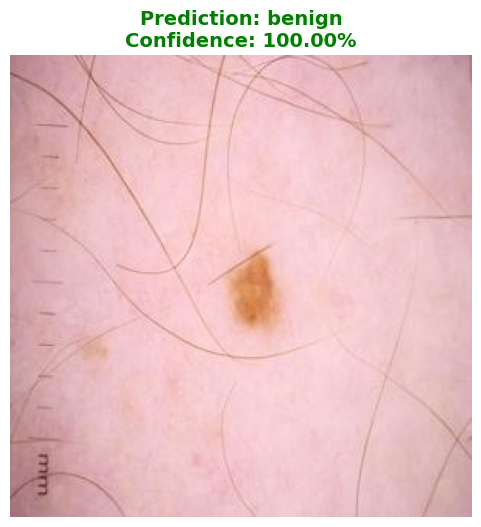

Image: melanoma_1062.jpg
Class: benign | Confidence: 100.00%


In [100]:
from PIL import Image
import torch.nn.functional as F

def predict_image(image_path, model, transform, device, class_names):
    # 1. Load and Preprocess
    # We keep the original image for plotting, but use the transform for the model
    original_image = Image.open(image_path).convert("RGB")
    input_tensor = transform(original_image).unsqueeze(0).to(device) # Add batch dimension

    # 2. Inference
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        outputs = model(input_tensor)
        # ResNet18 with CrossEntropy returns 2 raw values (logits)
        # We apply Softmax to turn them into probabilities that sum to 100%
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    label = class_names[predicted_idx.item()]
    score = confidence.item() * 100
    
    return original_image, label, score

def show_prediction(image_path, model, transform, device, class_names):
    img, label, confidence = predict_image(image_path, model, transform, device, class_names)

    # Visualization
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    
    # Change title color based on class (optional but looks professional)
    title_color = 'red' if label.lower() == 'malignant' else 'green'
    
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%", 
              fontsize=14, fontweight='bold', color=title_color)
    plt.show()

    print(f"Image: {image_path.split('/')[-1]}")
    print(f"Class: {label} | Confidence: {confidence:.2f}%")

# --- HOW TO RUN ---
# Ensure your class_names match your dataset: class_names = ['benign', 'malignant']
test_img_path = "/kaggle/input/datasets/rosekkhatiwada/cancer-classification/archive/melanoma_cancer_dataset/train/benign/melanoma_1062.jpg"

show_prediction(test_img_path, model, resnet_transform, device, class_names)